In [2]:
import numpy as np
import matplotlib.pyplot as plt

Caricamento dataset in corso...


C:\Users\angel\AppData\Local\Temp\ipykernel_3040\1398903042.py:51: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1]) # Lascia spazio per la barra laterale


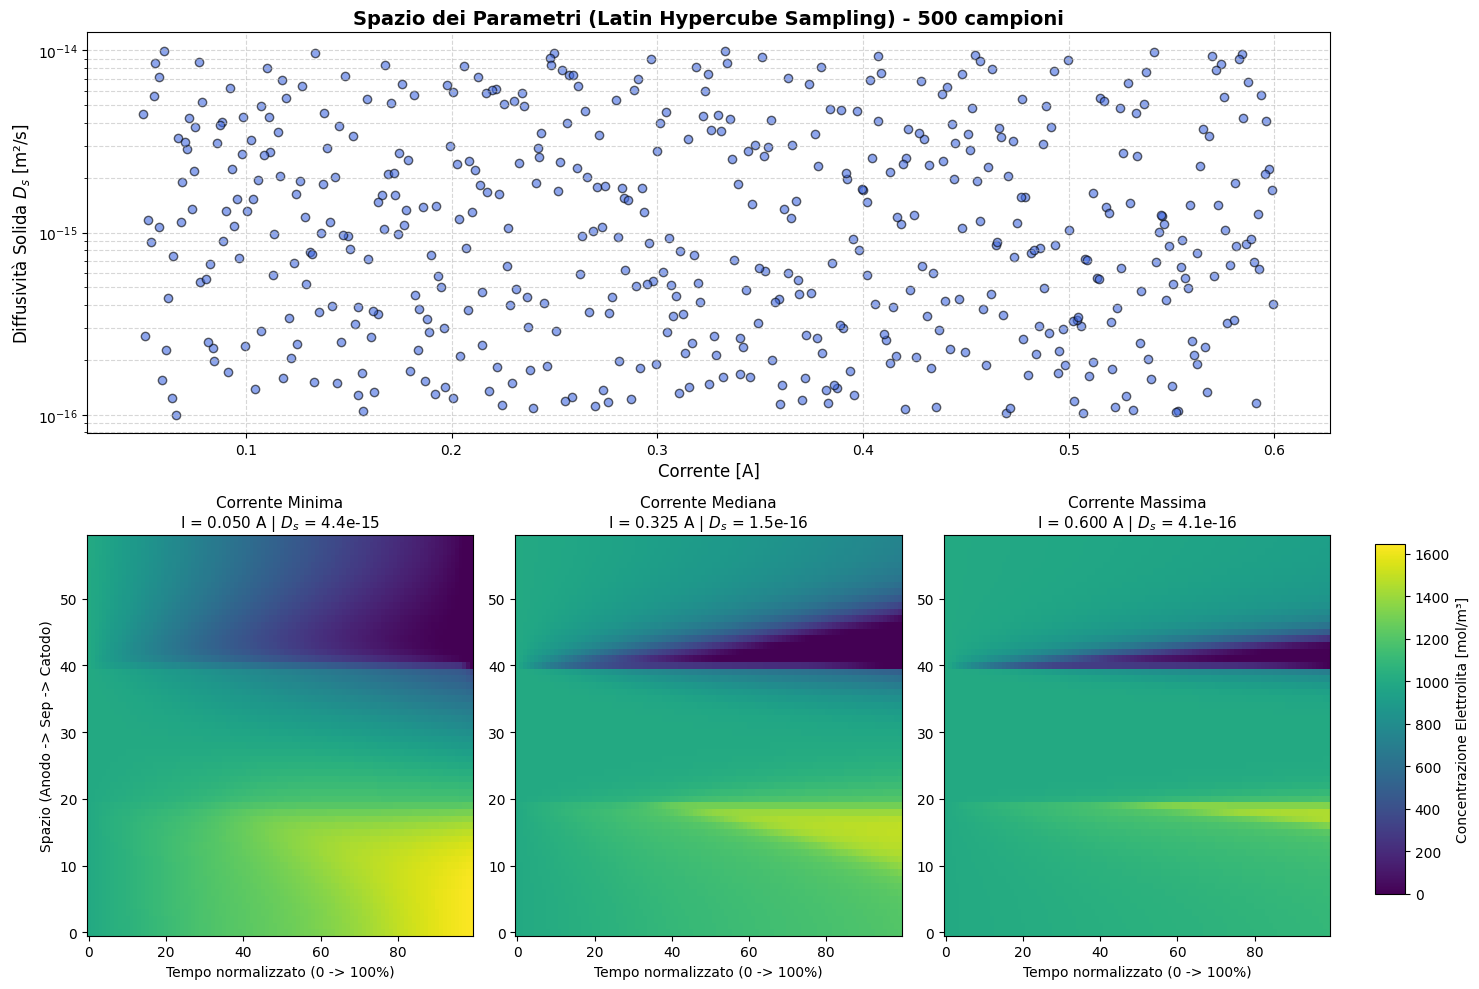

In [3]:
print("Caricamento dataset in corso...")
X = np.load('X_inputs_sodio.npy')
Y = np.load('Y_outputs_sodio.npy')

N_campioni = X.shape[0]
correnti = X[:, 0]
diffusivita = X[:, 1]

# 2 righe, la prima per LHS, la seconda per le heatmap
fig = plt.figure(figsize=(15, 10))

# --- GRAFICO 1: CAMPIONAMENTO LHS ---
ax1 = plt.subplot(2, 1, 1)
ax1.scatter(correnti, diffusivita, alpha=0.6, edgecolors='k', c='royalblue')
ax1.set_yscale('log') # (usiamo la scala logaritmica perché la diffusività varia per ordini di grandezza)
ax1.set_title(f'Spazio dei Parametri (Latin Hypercube Sampling) - {N_campioni} campioni', fontsize=14, fontweight='bold')
ax1.set_xlabel('Corrente [A]', fontsize=12)
ax1.set_ylabel('Diffusività Solida $D_s$ [m²/s]', fontsize=12)
ax1.grid(True, which="both", ls="--", alpha=0.5)

# --- GRAFICO 2: ESTRAZIONE DI 3 HEATMAP RAPPRESENTATIVE ---
# Cerchiamo gli indici di simulazioni con corrente Bassa, Media e Alta
idx_low = np.argmin(correnti)                     # La corrente più bassa testata
idx_high = np.argmax(correnti)                    # La corrente più alta testata
idx_mid = np.argsort(correnti)[N_campioni // 2]   # La corrente mediana

indici_da_mostrare = [idx_low, idx_mid, idx_high]
titoli = ['Corrente Minima', 'Corrente Mediana', 'Corrente Massima']

# Troviamo il min/max globale solo tra queste tre per la scala colori
vmin = np.min(Y[indici_da_mostrare])
vmax = np.max(Y[indici_da_mostrare])

for i, idx in enumerate(indici_da_mostrare):
    ax = plt.subplot(2, 3, 4 + i) # Posiziona i grafici nella seconda riga
    
    im = ax.imshow(Y[idx], aspect='auto', cmap='viridis', origin='lower', vmin=vmin, vmax=vmax)
    
    valore_I = X[idx, 0]
    valore_Ds = X[idx, 1]
    
    ax.set_title(f"{titoli[i]}\nI = {valore_I:.3f} A | $D_s$ = {valore_Ds:.1e}", fontsize=11)
    ax.set_xlabel('Tempo normalizzato (0 -> 100%)')
    if i == 0:
        ax.set_ylabel('Spazio (Anodo -> Sep -> Catodo)')

# Barra dei colori comune per le heatmap
cbar_ax = fig.add_axes([0.92, 0.1, 0.02, 0.35]) # Posizione custom per la barra
fig.colorbar(im, cax=cbar_ax, label='Concentrazione Elettrolita [mol/m³]')

plt.tight_layout(rect=[0, 0, 0.9, 1]) # Lascia spazio per la barra laterale
plt.show()